In [27]:
# Importo las librerías

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de estilo para los gráficos
sns.set_style("whitegrid")

In [28]:
DB_PATH = Path("../data/jobs.db") # Ruta al archivo de la base de datos "jobs.db"
conn = sqlite3.connect(DB_PATH) # Conecto a la base de datos "jobs.db"

df = pd.read_sql("SELECT * FROM jobs", conn) # Selecciono todos los datos de la tabla "jobs" y los guardo en un DataFrame

## Sección 1: Exploración inicial

In [29]:
# Vista previa de 5 filas aleatorias del DataFrame
df.sample(5)

,id,title,company,location,country,modality,salary_raw,description,date_raw,source,created_at
905,906,Senior Data Analyst,DiDi Global,"Ciudad de México, México",mx,NaN,NaN,DiDi Global Inc. is the world’s leading mobili...,2026-05-23T01:13:46Z,adzuna,2026-05-28 19:42:25
513,514,"Senior Data Analyst, Retail Analytics",Arc'Teryx,"North Vancouver, Greater Vancouver",ca,NaN,94000,Department : NAM - Retail Capabilities Reports...,2026-04-19T16:23:37Z,adzuna,2026-05-28 19:41:45
696,697,Senior Data Analyst (Web Analytics),NaN,Brasil,br,NaN,NaN,Senior Data Analyst (Web Analytics) - Sobre a ...,2026-05-25T18:48:01Z,adzuna,2026-05-28 19:42:05
558,559,Data Solutions Analyst,Terra Dygital Solutions,"Toronto, Ontario",ca,NaN,80000,Company Overview Terra Dygital Solutions is an...,2026-05-10T16:46:55Z,adzuna,2026-05-28 19:41:45
1069,1070,Digital Media Strategist - MX,Within,"Ciudad de México, México",mx,NaN,NaN,About you: Are you interested in expanding a c...,2024-10-30T06:26:22Z,adzuna,2026-05-28 19:42:25


In [30]:
# Dimensiones del dataset: filas y columnas
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

# Tipos de datos y valores nulos por columna
# Primer vistazo para saber qué limpiar y transformar
df.info()

Filas: 1311
Columnas: 11
<class 'pandas.DataFrame'>
RangeIndex: 1311 entries, 0 to 1310
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           1311 non-null   int64
 1   title        1311 non-null   str  
 2   company      1137 non-null   str  
 3   location     1311 non-null   str  
 4   country      1311 non-null   str  
 5   modality     24 non-null     str  
 6   salary_raw   363 non-null    str  
 7   description  1260 non-null   str  
 8   date_raw     1311 non-null   str  
 9   source       1311 non-null   str  
 10  created_at   1311 non-null   str  
dtypes: int64(1), str(10)
memory usage: 112.8 KB


In [31]:
# Porcentaje de valores nulos por columna
print("% de nulos")
print((df.isnull().sum() / len(df)) * 100)

% de nulos
id              0.000000
title           0.000000
company        13.272311
location        0.000000
country         0.000000
modality       98.169336
salary_raw     72.311213
description     3.890160
date_raw        0.000000
source          0.000000
created_at      0.000000
dtype: float64


salary_row y modality tienen una elevada cantidad de datos nulos

In [32]:
# Distribución de ofertas por país
df["country"].value_counts()

country
br    358
ca    236
mx    234
au    218
gb    144
us     70
ar     51
Name: count, dtype: int64

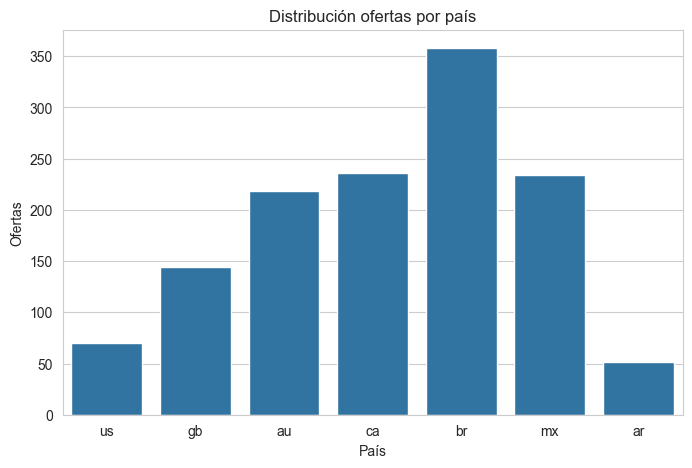

In [33]:
#Visualización de la distribución de ofertas por país
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='country')
plt.title('Distribución ofertas por país')
plt.xlabel('País')
plt.ylabel('Ofertas')
plt.show()

In [34]:
# Distribución de modalidad laboral
# Se esperan muchos nulos ya que Adzuna no provee este dato
df["modality"].value_counts(dropna=False)

modality
NaN                    1287
Presencial y remoto      22
Remoto                    2
Name: count, dtype: int64

Importante señalar que solo se muestran 22 modalidades, ya que el resto son datos nulos.

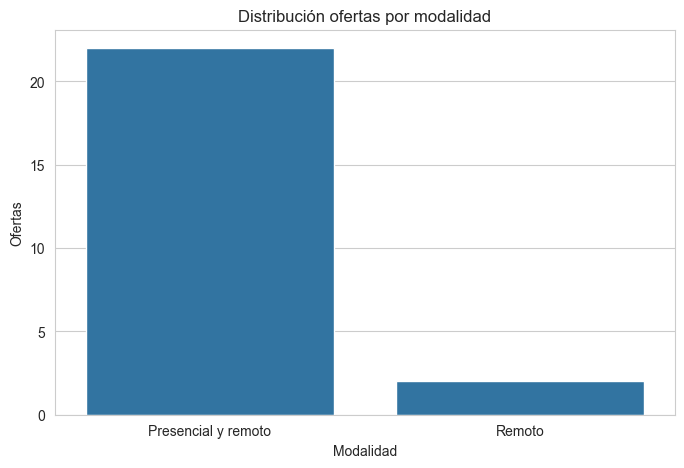

In [35]:
#Visualización de la distribución de modalidad laboral
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='modality')
plt.title('Distribución ofertas por modalidad')
plt.xlabel('Modalidad')
plt.ylabel('Ofertas')
plt.show()

## Sección 2: Limpieza y Normalización

In [36]:
# Se crea una copia del dataframe original para no modificar los datos crudos
df_clean = df.copy()

In [37]:
# Elimino espacios en blanco al inicio y al final de los textos
for col in ["title", "company", "location"]:
    df_clean[col] = df_clean[col].str.strip()

In [38]:
# Se rellena company nula con "Unknown" para no perder ofertas
df_clean["company"] = df_clean["company"].fillna("Unknown")

In [39]:
# Convierto date_raw a formato de fecha YYYY-MM-DD
# utc=True porque las fechas de Adzuna están en formato UTC
# errors="coerce" para convertir fechas inválidas a NaT (Not a Time) en lugar de lanzar un error
df_clean["date"] = pd.to_datetime(df_clean["date_raw"], utc=True, errors="coerce").dt.strftime("%Y-%m-%d")

# Verifico que todo esté correcto
df_clean[["company", "date_raw", "date"]].sample(15)

,company,date_raw,date
392,Hoban Recruitment,2026-05-01T21:17:31Z,2026-05-01
79,FDM Group,2026-05-21T19:10:01Z,2026-05-21
773,Nestle Operational Services Worldwide SA,2026-05-27T18:08:40Z,2026-05-27
1246,Amazon,2026-05-29T18:04:53Z,2026-05-29
927,Logitech,2026-03-21T22:29:59Z,2026-03-21
724,Unknown,2026-05-25T18:48:34Z,2026-05-25
151,SF Partners,2026-05-08T15:57:51Z,2026-05-08
1090,STI,Hace 7 días,NaN
8,Cayuse Holdings,2026-05-13T21:26:58Z,2026-05-13
469,York Region,2026-05-23T16:38:24Z,2026-05-23


- Este cambio de fechas es para los datos extraídos de Adzuna, ya que los de Computrabajo no vienen con ningún formato en especial
- Para darles un formato a las fechas extraídas de Computrabajo se va a requerir de un código más complejo y de hacer uso de la librería "re"

In [40]:
# Se verifica el formato de created_at en filas de Computrabajo
df_clean[df_clean["source"] == "computrabajo"][["date_raw", "created_at"]].sample(5)

,date_raw,created_at
1097,Hace 7 días,2026-05-28 19:42:38
1307,Hace 3 días,2026-05-29 23:17:09
1101,Hace 2 días,2026-05-28 19:42:38
1102,Hace 2 días,2026-05-28 19:42:38
1084,Hace 5 días,2026-05-28 19:42:38


created_at es la misma fecha en todos los registros, por lo que se la usara de fecha base para la transformación 

In [41]:
import re # Para trabajar con expresiones regulares en la función de parseo de fechas de Computrabajo

# Se define la función para convertir fechas relativas de Computrabajo a formato YYYY-MM-DD
def parse_date_computrabajo(date_raw: str, created_at: str) -> str:
    """
    Convierte fechas relativas en español de Computrabajo a formato YYYY-MM-DD.
    Usa created_at como fecha de referencia para calcular fechas relativas.
    
    Casos cubiertos:
    - "Hace X días"   → created_at - X días
    - "Hace X horas"  → created_at - X horas (se redondea al día)
    - "Ayer"          → created_at - 1 día
    - "19 de mayo"    → fecha absoluta del año de created_at
    - "Más de 30 días"→ NaT, ya que no logré encontrar una manera de interpretar esta fecha
    """
    # Normalizamos espacios múltiples internos
    # Convertimos a minúsculas para facilitar la comparación
    # Ejemplo: "  Hace   3   días " → "hace 3 días"
    text = re.sub(r"\s+", " ", str(date_raw)).strip().lower()
    
    # Fecha base: cuándo corrió el scraper
    # created_at es la fecha en formato string, lo convertimos a datetime para hacer cálculos
    base = pd.to_datetime(created_at)
    
    # "Ayer"
    # Si el texto es exactamente "ayer", restamos un día a la fecha base
    # Ejemplo: "ayer" → base - 1 día
    if text == "ayer":
        return (base - pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    
    # "Hace X días" o "Hace X horas"
    # Usamos expresiones regulares para extraer el número de días u horas
    # "hace 7 días" → encuentra match, captura "7"
    # "ayer"        → no encuentra match, devuelve None
    # Ejemplo: "hace 3 días" → match_dias.group(1) = "3"
    match_dias = re.search(r"hace (\d+) día", text)
    match_horas = re.search(r"hace (\d+) hora", text)
    
    # Si encontramos "hace X día(s)", restamos X días a la fecha base
    if match_dias:
        n = int(match_dias.group(1))
        return (base - pd.Timedelta(days=n)).strftime("%Y-%m-%d")
    
    # Si encontramos "hace X hora(s)", restamos X horas a la fecha base y redondeamos al día
    if match_horas:
        n = int(match_horas.group(1))
        return (base - pd.Timedelta(hours=n)).strftime("%Y-%m-%d")
    
    # "19 de mayo" → fecha absoluta
    meses = {
        "enero": 1, "febrero": 2, "marzo": 3, "abril": 4,
        "mayo": 5, "junio": 6, "julio": 7, "agosto": 8,
        "septiembre": 9, "octubre": 10, "noviembre": 11, "diciembre": 12
    }
    # Usamos una expresión regular para extraer el día y el mes
    # "19 de mayo" → match_fecha.group(1) = "19", match_fecha.group(2) = "mayo"
    # Ejemplo: "19 de mayo" → base.year-05-19
    match_fecha = re.search(r"(\d+) de (\w+)", text)
    if match_fecha:
        dia = int(match_fecha.group(1))
        mes = meses.get(match_fecha.group(2))
        if mes:
            return f"{base.year}-{mes:02d}-{dia:02d}"
    
    # "Más de 30 días" u otros no reconocidos
    return None

In [42]:
# Aplicamos la función de parseo a las filas de Computrabajo

df_clean["date"] = df_clean.apply(
    lambda row: (
        # Si es Computrabajo, se usa la función de parseo que creamos
        parse_date_computrabajo(row["date_raw"], row["created_at"])
        if row["source"] == "computrabajo"
        # Si es Adzuna, se mantiene el date que ya parseamos antes
        else row["date"]
    ),
    axis=1 # axis=1 significa que aplicamos la función fila por fila
)

# Verifico los resultados en ambas fuentes
df_clean[df_clean["source"] == "computrabajo"][["date_raw", "created_at", "date"]].sample(15)

,date_raw,created_at,date
1085,20 de mayo,2026-05-28 19:42:38,2026-05-20
1087,Hace 6 días,2026-05-28 19:42:38,2026-05-22
1304,Hace 16 horas,2026-05-29 23:17:09,2026-05-29
1071,Hace 12 horas,2026-05-28 19:42:38,2026-05-28
1110,Hace 7 días,2026-05-28 19:42:38,2026-05-21
1093,13 de mayo,2026-05-28 19:42:38,2026-05-13
1083,Hace 6 días,2026-05-28 19:42:38,2026-05-22
1074,Ayer,2026-05-28 19:42:38,2026-05-27
1105,Hace 3 días,2026-05-28 19:42:38,2026-05-25
1303,Hace 8 horas,2026-05-29 23:17:09,2026-05-29


In [43]:
# Normalizo los valores de modalidad a inglés
# Solo exiten 2 valores en computrabajo: "Remoto" y "Presencial y remoto"
# El resto son nulos → quedan como NaN

MODALITY_MAP = {
    "Remoto": "Remote",
    "Presencial y remoto": "Hybrid",
}

df_clean["modality"] = df_clean["modality"].map(MODALITY_MAP)

# Verifico los resultados
df_clean["modality"].value_counts(dropna=False)

modality
NaN       1287
Hybrid      22
Remote       2
Name: count, dtype: int64

In [44]:
# Reviso el formato de los salarios en computrabajo para ver cómo transformarlos
df_clean[df_clean["source"] == "computrabajo"]["salary_raw"].value_counts(dropna=False)

salary_raw
NaN                                      39
$ 1.111.111,00 (Mensual)                  3
$ 1.000.000,00 (Mensual) + Comisiones     3
$ 1.300.000,00 (Mensual)                  2
$ 111.111,00 (Mensual)                    1
$ 10.000,00 (Mensual)                     1
$ 2.000,00 (Mensual)                      1
$ 11.111,00 (Mensual)                     1
Name: count, dtype: int64

In [ ]:
def parse_salary(salary_raw: str, source: str) -> float:
    """
    Convierte salary_raw a float según la fuente.
    
    Adzuna: "62305.64" → 62305.64
    Computrabajo: "$ 1.111.111,00 (Mensual)" → 1111111.0
    Devuelve None si es nulo o no se puede convertir.
    """
    if pd.isna(salary_raw):
        return None
    
    if source == "adzuna":
        try:
            return float(salary_raw)
        except ValueError:
            return None
    
    if source == "computrabajo":
        # Elimina todo excepto dígitos, puntos y comas
        cleaned = re.sub(r"[^\d.,]", "", salary_raw) # [^\d.,] significa dígitos, puntos y comas, el ^ dentro de los corchetes niega el conjunto, por lo que se eliminan todos los caracteres que no sean dígitos, puntos o comas
        # Formato argentino: punto como separador de miles, coma como decimal
        # "1.111.111,00" → "1111111.00"
        cleaned = cleaned.replace(".", "").replace(",", ".")
        try:
            return float(cleaned)
        except ValueError:
            return None

# Aplica la función fila por fila
df_clean["salary_clean"] = df_clean.apply(
    lambda row: parse_salary(row["salary_raw"], row["source"]), # Llama a parse_salary con los valores de salary_raw y source de cada fila
    axis=1
)

# Verificamos
print(df_clean[["salary_raw", "salary_clean", "source"]].dropna(subset=["salary_raw"]).sample(10))
print("=" * 40)
print(df_clean[df_clean["source"] == "computrabajo"]["salary_clean"].value_counts(dropna=False))

     salary_raw  salary_clean  source
118       22880      22880.00  adzuna
54     86169.03      86169.03  adzuna
1130   35018.26      35018.26  adzuna
571       40000      40000.00  adzuna
1041          1          1.00  adzuna
501       93600      93600.00  adzuna
59     74177.58      74177.58  adzuna
1125      35000      35000.00  adzuna
168       93600      93600.00  adzuna
182       91000      91000.00  adzuna
salary_clean
NaN          39
1111111.0     3
1000000.0     3
1300000.0     2
111111.0      1
10000.0       1
2000.0        1
11111.0       1
Name: count, dtype: int64


In [46]:
# Vemos salary_raw por país para entender qué moneda usa cada uno
df_clean[df_clean["salary_raw"].notna()][["country", "salary_raw"]].groupby("country").head(2)

,country,salary_raw
0,us,62305.64
1,us,94013.06
63,gb,30000
64,gb,25000
219,au,156000
230,au,75000
396,ca,110000
400,ca,62400
624,br,360
629,br,18000


In [51]:
# Vemos los tipos de datos finales para asegurarnos que todo esté correcto
df_clean.dtypes

id                int64
title               str
company             str
location            str
country             str
modality            str
salary_raw          str
description         str
date_raw            str
source              str
created_at          str
date                str
salary_clean    float64
dtype: object

In [47]:
# Guardo jobs_clean en la base de datos como tabla "jobs_clean" 
df_clean.to_sql("jobs_clean", conn, if_exists="replace", index=False)
print(f"Tabla jobs_clean guardada: {len(df_clean)} filas")

Tabla jobs_clean guardada: 1311 filas


## Sección 3: Análisis y Gráficos